In [2]:
%pip -q install langchain langgraph python-dotenv langsmith langchain_core langchain_community langchain-openai

Note: you may need to restart the kernel to use updated packages.


In [83]:
from dotenv import load_dotenv
import os


load_dotenv()



True

In [10]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gpt-4o", model_provider="openai")



In [11]:
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage

message = [HumanMessage(content="Hi, I am Anupam")]
message.extend([HumanMessage(content="Hi, I love to eat panner")])
message.extend([HumanMessage(content="Hi, my age is 25")])

question = [HumanMessage(content="What is my age and Name?")]
print(llm.invoke(message+question))

content='Your name is Anupam, and you are 25 years old.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 48, 'total_tokens': 63, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': None, 'id': 'chatcmpl-Bssz86ChcU7YGYQf6plHLhJCKPeq8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--189be109-63c1-4b39-9dc0-7cac3d2cbd00-0' usage_metadata={'input_tokens': 48, 'output_tokens': 15, 'total_tokens': 63, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [ ]:
def mult(a:int, b:int):
    """This function will take two numbers and multiply them and send result back"""
    return a*b

def weathr(query:str):
    """This tool will provide wather info"""
    return ""

llmwithlool=llm.bind_tools([mult, weathr])

res=llmwithlool.invoke([HumanMessage(content="multiply 2 and  5")])
print(res)
if isinstance(res,AIMessage):
    for x in res:
        pass


content='' additional_kwargs={'tool_calls': [{'id': 'call_8xjQixndP753pgW4iKaSJuQj', 'function': {'arguments': '{"a":2,"b":5}', 'name': 'mult'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 84, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': None, 'id': 'chatcmpl-BstAtO2Xn3OjwVg92dv7vpxukGVsY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='run--e9b17198-c46f-42e0-8a56-a747333c8eac-0' tool_calls=[{'name': 'mult', 'args': {'a': 2, 'b': 5}, 'id': 'call_8xjQixndP753pgW4iKaSJuQj', 'type': 'tool_call'}] usage_metadata={'input_tokens': 84, 'output_tokens': 17, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': 

In [20]:
from langgraph.graph.message import MessagesState, add_messages
from typing import Annotated, List, TypedDict
from langchain_core.messages import AnyMessage


class State(TypedDict):
    messages:Annotated[List[AnyMessage], add_messages()]




In [21]:
def chatbot(state:State):
    res = [llmwithlool.invoke(state["messages"])]
    state["messages"] = res

    return state

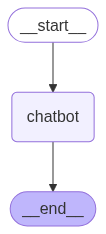

In [28]:
from langgraph.graph import START, END, StateGraph
from IPython.display import display, Image
from langgraph.checkpoint.memory import MemorySaver

ms = MemorySaver()
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile(checkpointer=ms)
display(Image(graph.get_graph().draw_mermaid_png()))



In [55]:
res = graph.invoke({"messages":HumanMessage(content="What is My name?")},config={"configurable":{"thread_id":1}})

In [56]:
from pprint import pprint
print(res)

{'messages': [HumanMessage(content='How Are you?', additional_kwargs={}, response_metadata={}, id='ca72bb26-376d-4335-8d90-c7128c633523'), AIMessage(content="I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help you with anything you need! How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 81, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': None, 'id': 'chatcmpl-BstjwP3zWJe7XgkgLrODLUoZZb1JA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--099e53a6-b580-47e0-bd1f-0d871b7079d6-0', usage_metadata={'input_tokens': 81, 'output_tokens': 33, 'total_tokens': 114, 'input_token_details': {'audio': 0, 'cache

In [57]:
import requests
load_dotenv()

def weather(city:str)->dict:

    """This Tool will take input as City name and provide current weather realated information in detail"""

    BASE_URL = "https://api.weatherapi.com/v1/current.json"
    params  = {
        "key": os.environ.get("WEATHER_API"),
        "q":city,
        "aqi": "no"
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code==200:
        return response.json()
        
    return response.json()



In [58]:
toolcallingllm = llm.bind_tools([mult, weather])

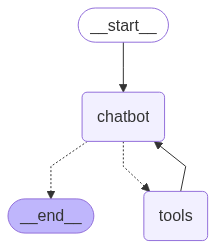

In [80]:
from langgraph.graph import StateGraph, add_messages
from typing import TypedDict, Annotated, List
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import AnyMessage

ms=MemorySaver()

class State(TypedDict):
    messages : Annotated[List[AnyMessage], add_messages]

def chatbot(state:State):
    response = toolcallingllm.invoke(state['messages'])
    state['messages'] = response
    return state

builder=StateGraph(State)

builder.add_node("chatbot",chatbot)
builder.add_node("tools",ToolNode([mult,weather]))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot",tools_condition)
builder.add_edge("tools", "chatbot")

graph=builder.compile(ms)

display(Image(graph.get_graph().draw_mermaid_png()))


In [82]:
from langchain_core.messages import HumanMessage

mess=[HumanMessage(content="Current Weather of Kolkata and 2 multiply 6")]

config ={"configurable": {"thread_id": "1"}}
 # thread_id as string is safer

response = graph.invoke({"messages":mess},config)

print(response)


{'messages': [HumanMessage(content='Current Weather of Kolkata', additional_kwargs={}, response_metadata={}, id='92b18f16-735b-4cb2-ba91-63c08a79e39d'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_nAzpgDAA4H3TnT3lLywIVZ2w', 'function': {'arguments': '{"city":"Kolkata"}', 'name': 'weather'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 89, 'total_tokens': 104, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': None, 'id': 'chatcmpl-BsuYnBHd8vXOIKNfOl3mF4tuepcPr', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--8808fb1d-6135-4879-a956-44e4c9430af8-0', tool_calls=[{'name': 'weather', 'args': {'city': 'Kolkata'}, 'id': 'call_nAzpgDAA4H3TnT3lLywIVZ2w